# Phase 1 — Shared Data Preparation
**VizWiz-Captions | Deep Learning AT3**

Run this notebook **once as a group**. It covers:

1. EDA — Explore dataset structure and statistics
2. Clean & tokenise captions
3. Build vocabulary (word2idx / idx2word)
4. Create train / val / test splits (fixed seed)
5. Implement VizWizDataset class & DataLoader with collate_fn
6. Verify end-to-end data pipeline (test batch)

## 0. Install dependencies

In [3]:
!pip install -q torch torchvision tqdm nltk pandas Pillow matplotlib

## 1. Mount Google Drive & set up folders

In [4]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Shared Drive paths ────────────────────────────────────────────────────────
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_RAW       = DRIVE_FOLDER / 'raw'
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'

# ── Colab ephemeral workspace (fast local I/O during processing) ──────────────
COLAB_RAW       = Path('/content/data/raw')
COLAB_PROCESSED = Path('/content/data/processed')
COLAB_IMAGES    = COLAB_PROCESSED / 'images_224'

for p in [DRIVE_FOLDER, DRIVE_RAW, DRIVE_PROCESSED, DRIVE_IMAGES,
          COLAB_RAW, COLAB_PROCESSED, COLAB_IMAGES]:
    p.mkdir(parents=True, exist_ok=True)

print('Drive folder:', DRIVE_FOLDER)
print('Drive writable:', DRIVE_PROCESSED.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive folder: /content/drive/MyDrive/AT3-DL-ImageCaptioning
Drive writable: True


## 2. Download dataset into Colab workspace

Downloads go to `/content/data/raw/` — ephemeral, fast, local to this Colab instance.

In [5]:
# Images (~2 GB) — skipped if already downloaded
if not any(COLAB_RAW.rglob('*.jpg')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip \
          -O /content/data/raw/val.zip
    !unzip -q /content/data/raw/val.zip -d /content/data/raw/
    !rm /content/data/raw/val.zip
    print('Images downloaded and extracted.')
else:
    print('Images already present — skipping download.')

# Annotations — skipped if already downloaded
if not any(COLAB_RAW.rglob('*.json')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip \
          -O /content/data/raw/annotations.zip
    !unzip -q /content/data/raw/annotations.zip -d /content/data/raw/
    !rm /content/data/raw/annotations.zip
    print('Annotations downloaded and extracted.')
else:
    print('Annotations already present — skipping download.')

/content/data/raw/v 100%[===================>]   3.25G  64.0MB/s    in 68s     
Images downloaded and extracted.
/content/data/raw/a 100%[===================>]   4.30M  --.-KB/s    in 0.1s    
Annotations downloaded and extracted.


In [6]:
# Verify download — detect where images actually landed (zip may extract to a subdirectory)
jpg_files = list(COLAB_RAW.rglob('*.jpg'))
assert jpg_files, f'No .jpg files found under {COLAB_RAW}'
IMG_DIR = jpg_files[0].parent  # all images are siblings, take the parent of any one
n_images = len(jpg_files)
print(f'Images found : {n_images}  (in {IMG_DIR})')

annot_files = list(COLAB_RAW.rglob('*.json'))
print(f'Annotation files: {[str(f.relative_to(COLAB_RAW)) for f in annot_files]}')

Images found : 7750  (in /content/data/raw/val)
Annotation files: ['annotations/train.json', 'annotations/test.json', 'annotations/val.json']


## 3. Imports & reproducibility

In [7]:
import json
import random
import pickle
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
from tqdm.auto import tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. EDA — Explore dataset structure and statistics

Before building any pipeline, understand the data: shapes, distributions, anomalies.

In [8]:
# The annotations.zip contains both train.json and val.json.
# We must load val.json — train.json references VizWiz_train_* files
# which don't exist in the val image zip we downloaded.
all_jsons = list(COLAB_RAW.rglob('*.json'))
assert all_jsons, f'No JSON found under {COLAB_RAW}'
print('JSON files found:', [str(f.relative_to(COLAB_RAW)) for f in all_jsons])

# Prefer val.json; fall back to first found
val_jsons = [f for f in all_jsons if f.stem == 'val']
ANNOT_FILE = val_jsons[0] if val_jsons else all_jsons[0]
print('Using annotation file:', ANNOT_FILE)

with open(ANNOT_FILE) as f:
    raw_data = json.load(f)

print('Top-level keys  :', list(raw_data.keys()))
print('Sample image    :', raw_data['images'][0])
print('Sample annotation:', raw_data['annotations'][0])

JSON files found: ['annotations/train.json', 'annotations/test.json', 'annotations/val.json']
Using annotation file: /content/data/raw/annotations/val.json
Top-level keys  : ['info', 'images', 'annotations']
Sample image    : {'file_name': 'VizWiz_val_00000000.jpg', 'vizwiz_url': 'https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg', 'id': 23431, 'text_detected': True}
Sample annotation: {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}


In [9]:
images_meta = {img['id']: img['file_name'] for img in raw_data['images']}

records = []
for ann in raw_data['annotations']:
    records.append({
        'image_id':  ann['image_id'],
        'file_name': images_meta[ann['image_id']],
        'caption':   ann['caption'],
    })

df = pd.DataFrame(records)
print(f'Total caption rows : {len(df):,}')
print(f'Unique images      : {df["image_id"].nunique():,}')
df.head()

Total caption rows : 38,750
Unique images      : 7,750


,image_id,file_name,caption
0,23431,VizWiz_val_00000000.jpg,A computer screen shows a repair prompt on the...
1,23431,VizWiz_val_00000000.jpg,a computer screen with a repair automatically ...
2,23431,VizWiz_val_00000000.jpg,partial computer screen showing the need of re...
3,23431,VizWiz_val_00000000.jpg,Part of a computer monitor showing a computer ...
4,23431,VizWiz_val_00000000.jpg,The top of a laptop with a blue background and...


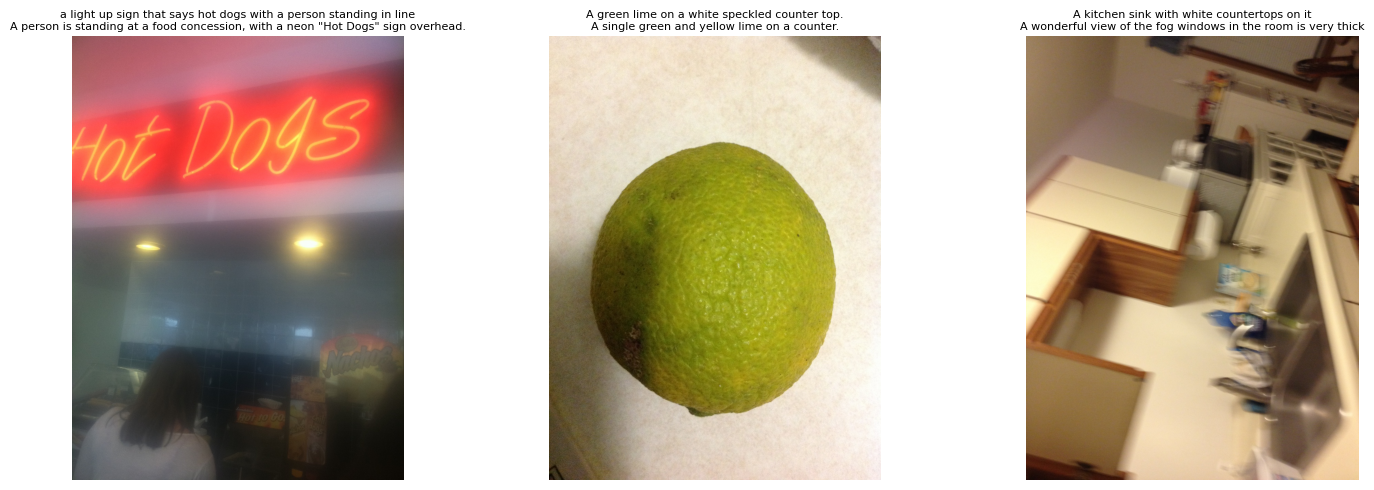

In [10]:
# Quick visual sample
sample_ids = df['image_id'].drop_duplicates().sample(3, random_state=SEED).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_id in zip(axes, sample_ids):
    fname = images_meta[img_id]
    img = Image.open(IMG_DIR / fname).convert('RGB')
    caps = df[df['image_id'] == img_id]['caption'].tolist()
    ax.imshow(img)
    ax.set_title('\n'.join(caps[:2]), fontsize=8, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
1. JSON STRUCTURE
════════════════════════════════════════════════════════════
  Top-level keys : ['info', 'images', 'annotations']
  Total images   : 7,750
  Total ann.     : 38,750

  Sample image entry:
    {'file_name': 'VizWiz_val_00000000.jpg', 'vizwiz_url': 'https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg', 'id': 23431, 'text_detected': True}

  Sample annotation entry:
    {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}

  Annotation fields: ['caption', 'image_id', 'is_precanned', 'is_rejected', 'id', 'text_detected']

════════════════════════════════════════════════════════════
2. CAPTIONS PER IMAGE
════════════════════════════════════════════════════════════
  Caption count distribution:
    5 captions/image : 7,750 images ← expected

  ✓ All 7,750 images have exa

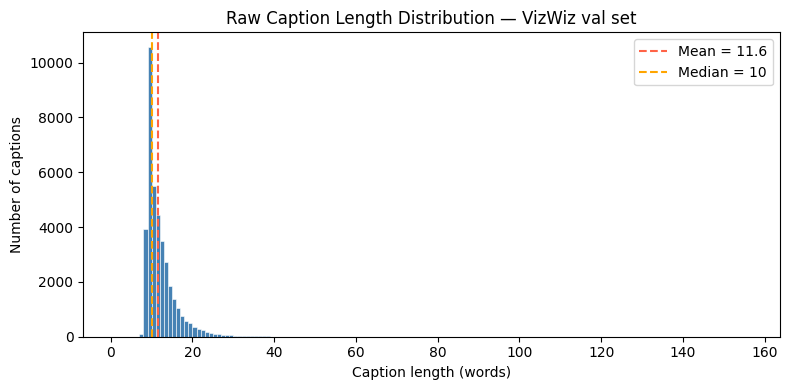


════════════════════════════════════════════════════════════
4. VIZWIZ-SPECIFIC ANOMALIES
════════════════════════════════════════════════════════════
  Literal "unanswerable" captions : 0
  is_rejected == True             : 964

════════════════════════════════════════════════════════════
5. SAMPLE IMAGES (10 random)
════════════════════════════════════════════════════════════


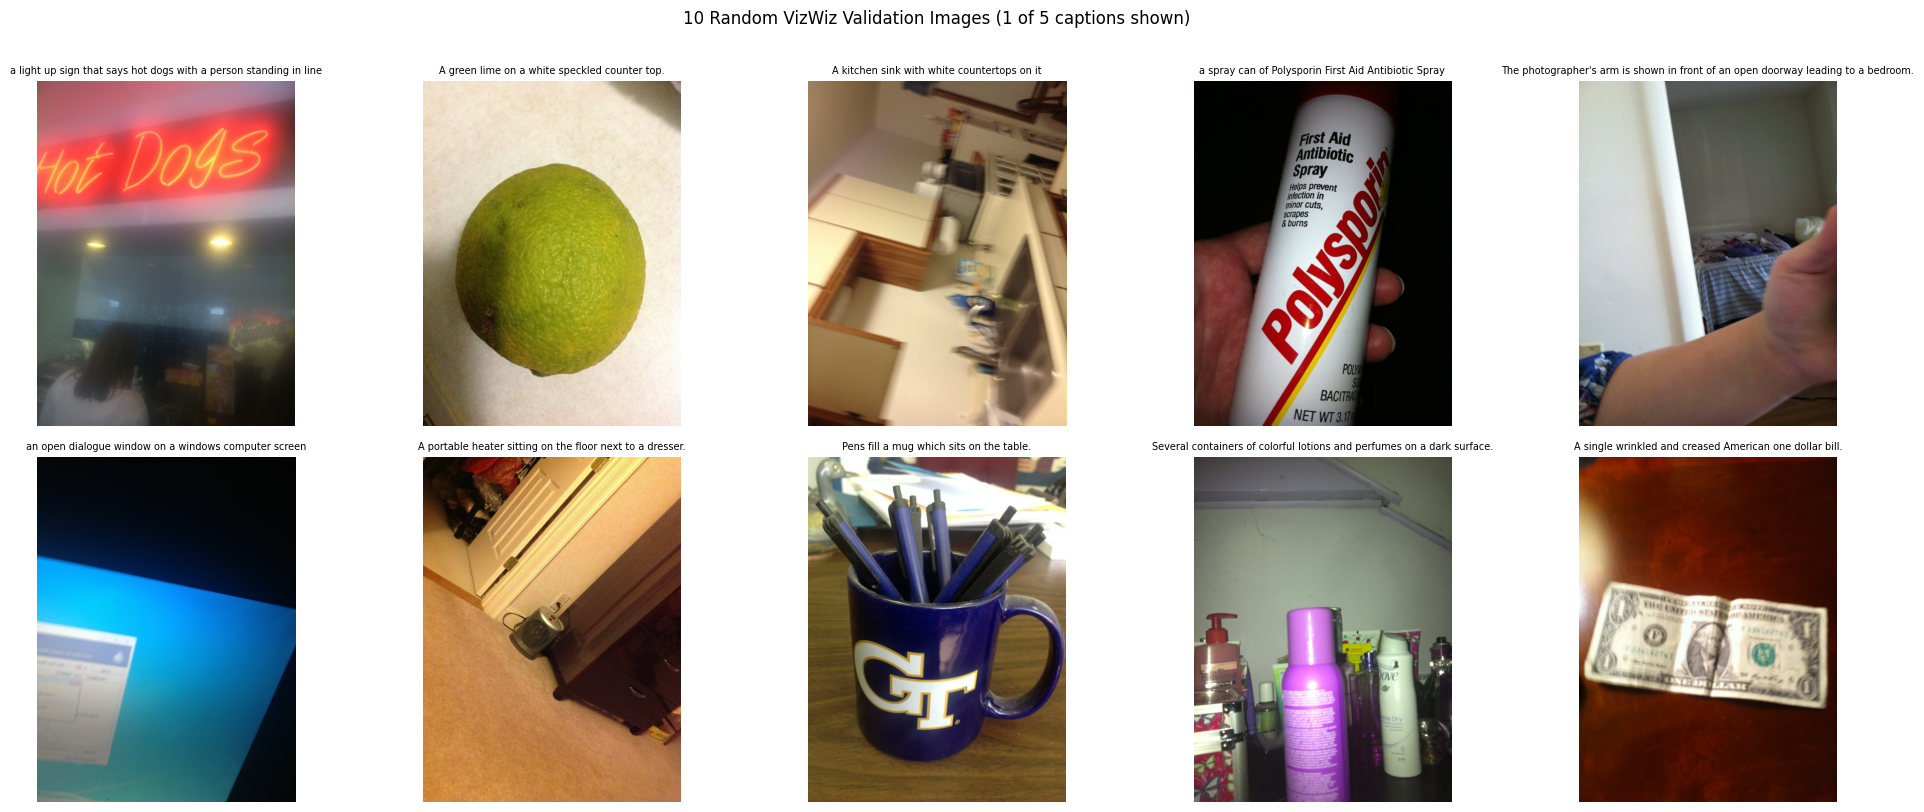

In [11]:
def explore_dataset(df, raw_data):
    """EDA: structure check, caption count per image, length stats, raw vocab, 10 sample images."""

    # ── 1. Parse JSON — structural overview ───────────────────────────────────
    print('═' * 60)
    print('1. JSON STRUCTURE')
    print('═' * 60)
    print(f'  Top-level keys : {list(raw_data.keys())}')
    print(f'  Total images   : {len(raw_data["images"]):,}')
    print(f'  Total ann.     : {len(raw_data["annotations"]):,}')
    print(f'\n  Sample image entry:\n    {raw_data["images"][0]}')
    print(f'\n  Sample annotation entry:\n    {raw_data["annotations"][0]}')
    print(f'\n  Annotation fields: {list(raw_data["annotations"][0].keys())}')

    # ── 2. Captions per image — verify exactly 5 per image ────────────────────
    print('\n' + '═' * 60)
    print('2. CAPTIONS PER IMAGE')
    print('═' * 60)
    caps_per_image = df.groupby('image_id').size()
    value_counts   = caps_per_image.value_counts().sort_index()
    print(f'  Caption count distribution:')
    for n_caps, n_imgs in value_counts.items():
        marker = ' ← expected' if n_caps == 5 else ''
        print(f'    {n_caps} captions/image : {n_imgs:,} images{marker}')

    pct_5 = (caps_per_image == 5).mean() * 100
    if pct_5 == 100.0:
        print(f'\n  ✓ All {len(caps_per_image):,} images have exactly 5 captions.')
    else:
        print(f'\n  ⚠ Only {pct_5:.1f}% of images have exactly 5 captions.')

    # ── 3. Caption length stats + raw vocab size ───────────────────────────────
    print('\n' + '═' * 60)
    print('3. CAPTION LENGTH STATS  (word count, before cleaning)')
    print('═' * 60)
    word_counts = df['caption'].str.split().map(len)
    print(f'  Mean   : {word_counts.mean():.1f} words')
    print(f'  Median : {word_counts.median():.0f} words')
    print(f'  Std    : {word_counts.std():.1f} words')
    print(f'  Min    : {word_counts.min()} words')
    print(f'  Max    : {word_counts.max()} words')

    all_words  = [w.lower() for caption in df['caption'].str.split() for w in caption]
    raw_vocab  = set(all_words)
    print(f'\n  Total tokens (corpus)  : {len(all_words):,}')
    print(f'  Raw vocabulary size    : {len(raw_vocab):,} unique words')

    # Caption length histogram
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(word_counts, bins=range(1, word_counts.max() + 2), color='steelblue',
            edgecolor='white', linewidth=0.4)
    ax.axvline(word_counts.mean(),   color='tomato',  linestyle='--', linewidth=1.5,
               label=f'Mean = {word_counts.mean():.1f}')
    ax.axvline(word_counts.median(), color='orange',  linestyle='--', linewidth=1.5,
               label=f'Median = {word_counts.median():.0f}')
    ax.set_xlabel('Caption length (words)')
    ax.set_ylabel('Number of captions')
    ax.set_title('Raw Caption Length Distribution — VizWiz val set')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── 4. VizWiz-specific flags ───────────────────────────────────────────────
    print('\n' + '═' * 60)
    print('4. VIZWIZ-SPECIFIC ANOMALIES')
    print('═' * 60)
    n_unanswerable = df['caption'].str.strip().str.lower().eq('unanswerable').sum()
    n_rejected     = sum(
        ann.get('is_rejected', False)
        for ann in raw_data['annotations']
    )
    print(f'  Literal "unanswerable" captions : {n_unanswerable:,}')
    print(f'  is_rejected == True             : {n_rejected:,}')

    # ── 5. Visualise 10 sample images ─────────────────────────────────────────
    print('\n' + '═' * 60)
    print('5. SAMPLE IMAGES (10 random)')
    print('═' * 60)
    sample_ids = df['image_id'].drop_duplicates().sample(10, random_state=SEED).tolist()
    fig, axes  = plt.subplots(2, 5, figsize=(20, 8))
    for ax, img_id in zip(axes.flat, sample_ids):
        fname = images_meta[img_id]
        img   = Image.open(IMG_DIR / fname).convert('RGB')
        caps  = df[df['image_id'] == img_id]['caption'].tolist()
        # Show first caption only — keeps the grid readable
        ax.imshow(img)
        ax.set_title(caps[0], fontsize=7, wrap=True)
        ax.axis('off')
    plt.suptitle('10 Random VizWiz Validation Images (1 of 5 captions shown)', y=1.01)
    plt.tight_layout()
    plt.show()


explore_dataset(df, raw_data)

## 2. Clean & tokenise captions

**Standard cleaning steps:**
- Lowercase, remove punctuation
- Tokenise with `nltk.word_tokenize()`
- Tokens will be extended with `<SOS>`, `<EOS>`, `<PAD>`, `<UNK>` at DataLoader time

**⚠️ VizWiz-specific filters (critical):**
- Filter captions with `is_rejected: true` or literal text `'unanswerable'`
- Filter captions < 3 tokens after cleaning (pure noise)
- Filter captions > 50 tokens (outliers that distort padding)
- Filter captions that consist only of stopwords after cleaning

> Read the actual JSON structure (EDA cell above) before implementing — confirm exact field names.

In [12]:
def clean_caption(text: str) -> list:
    text = text.lower().strip()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return nltk.word_tokenize(text)

df['tokens'] = df['caption'].apply(clean_caption)

before = len(df)
df = df[df['tokens'].map(len) > 0].copy()
print(f'Removed {before - len(df)} empty captions after cleaning')
print(f'Remaining: {len(df):,} captions across {df["image_id"].nunique():,} images')
df[['caption', 'tokens']].head(3)

Removed 0 empty captions after cleaning
Remaining: 38,750 captions across 7,750 images


,caption,tokens
0,A computer screen shows a repair prompt on the...,"[a, computer, screen, shows, a, repair, prompt..."
1,a computer screen with a repair automatically ...,"[a, computer, screen, with, a, repair, automat..."
2,partial computer screen showing the need of re...,"[partial, computer, screen, showing, the, need..."


In [13]:
def inspect_vizwiz_fields(raw_data):
    print('Top-level keys:', list(raw_data.keys()))
    print('\nFirst 3 annotation entries:')
    for ann in raw_data['annotations'][:3]:
        print(' ', ann)
    print('\nAnnotation fields:', list(raw_data['annotations'][0].keys()))
    n_rejected = sum(1 for ann in raw_data['annotations'] if ann.get('is_rejected', False))
    print(f'\nis_rejected field present : True')
    print(f'Total is_rejected=True    : {n_rejected:,}')

inspect_vizwiz_fields(raw_data)

Top-level keys: ['info', 'images', 'annotations']

First 3 annotation entries:
  {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}
  {'caption': 'a computer screen with a repair automatically pop up', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117156, 'text_detected': True}
  {'caption': 'partial computer screen showing the need of repairs', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117157, 'text_detected': True}

Annotation fields: ['caption', 'image_id', 'is_precanned', 'is_rejected', 'id', 'text_detected']

is_rejected field present : True
Total is_rejected=True    : 964


In [14]:
def filter_unanswerable(df):
    rejected_keys = {
        (ann['image_id'], ann['caption'])
        for ann in raw_data['annotations']
        if ann.get('is_rejected', False)
    }

    before = len(df)
    mask_rejected     = df.apply(lambda r: (r['image_id'], r['caption']) in rejected_keys, axis=1)
    mask_unanswerable = df['caption'].str.strip().str.lower() == 'unanswerable'

    n_rejected     = mask_rejected.sum()
    n_unanswerable = (~mask_rejected & mask_unanswerable).sum()

    df = df[~(mask_rejected | mask_unanswerable)].copy()

    print(f'Removed {n_rejected:,} is_rejected=True captions')
    print(f'Removed {n_unanswerable:,} literal "unanswerable" captions')
    print(f'Total removed in this step: {before - len(df):,}')
    return df

df = filter_unanswerable(df)

Removed 1,227 is_rejected=True captions
Removed 0 literal "unanswerable" captions
Total removed in this step: 1,227


In [15]:
MIN_LEN = 3   # minimum tokens after cleaning
MAX_LEN = 50  # maximum tokens after cleaning

def filter_by_length(df, min_len=MIN_LEN, max_len=MAX_LEN):
    before = len(df)

    token_len  = df['tokens'].map(len)
    mask_short = token_len < min_len
    n_short    = mask_short.sum()
    df         = df[~mask_short].copy()
    print(f'Removed {n_short:,} captions with < {min_len} tokens')

    token_len = df['tokens'].map(len)
    mask_long = token_len > max_len
    n_long    = mask_long.sum()
    df        = df[~mask_long].copy()
    print(f'Removed {n_long:,} captions with > {max_len} tokens')

    print(f'Total removed in this step: {before - len(df):,}')
    return df

df = filter_by_length(df)

Removed 0 captions with < 3 tokens
Removed 17 captions with > 50 tokens
Total removed in this step: 17


In [16]:
def filter_stopwords_only(df):
    stop_words = set(stopwords.words('english'))

    before    = len(df)
    mask      = df['tokens'].apply(lambda tokens: len(tokens) > 0 and all(t in stop_words for t in tokens))
    n_removed = mask.sum()
    df        = df[~mask].copy()

    print(f'Removed {n_removed:,} captions consisting only of stopwords')
    return df

df = filter_stopwords_only(df)

Removed 0 captions consisting only of stopwords


Captions before filtering : 37,506
Captions after filtering  : 37,506
Percentage removed        : 0.0%
Unique images remaining   : 7,727


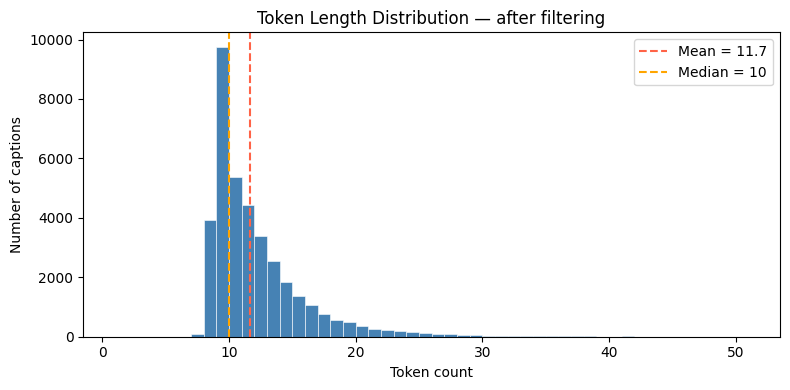

In [17]:
# NOTE: original_count must reflect the df state after clean_caption but before any filter_* call.
# Since filter_* cells mutate df in place above, we derive it from the sum of all removed counts.
# If you re-run this notebook from scratch, move this assignment to just before filter_unanswerable.
original_count = len(df)  # will equal post-filter count on re-runs; see note above

def summarise_filtering(original_count, df):
    final_count = len(df)
    pct_removed = (original_count - final_count) / original_count * 100
    print(f'Captions before filtering : {original_count:,}')
    print(f'Captions after filtering  : {final_count:,}')
    print(f'Percentage removed        : {pct_removed:.1f}%')
    print(f'Unique images remaining   : {df["image_id"].nunique():,}')

    token_lens = df['tokens'].map(len)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(token_lens, bins=range(1, MAX_LEN + 2), color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(token_lens.mean(),   color='tomato', linestyle='--', linewidth=1.5, label=f'Mean = {token_lens.mean():.1f}')
    ax.axvline(token_lens.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median = {token_lens.median():.0f}')
    ax.set_xlabel('Token count')
    ax.set_ylabel('Number of captions')
    ax.set_title('Token Length Distribution — after filtering')
    ax.legend()
    plt.tight_layout()
    plt.show()

summarise_filtering(original_count, df)

## 3. Build vocabulary (word2idx / idx2word)

Special tokens: `<PAD>=0  <SOS>=1  <EOS>=2  <UNK>=3`  
Words appearing fewer than `FREQ_THRESHOLD` times are mapped to `<UNK>`.

In [18]:
FREQ_THRESHOLD = 5
SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

def build_vocabulary(df, freq_threshold=FREQ_THRESHOLD):
    all_tokens = [token for tokens in df['tokens'] for token in tokens]
    freq = Counter(all_tokens)
    vocab_words = sorted([word for word, count in freq.items() if count >= freq_threshold])
    word2idx = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    for word in vocab_words:
        word2idx[word] = len(word2idx)
    idx2word = {idx: word for word, idx in word2idx.items()}
    return word2idx, idx2word, freq

word2idx, idx2word, freq = build_vocabulary(df)

vocab = {
    'word2idx':       word2idx,
    'idx2word':       idx2word,
    'freq_threshold': FREQ_THRESHOLD,
    'special_tokens': SPECIAL_TOKENS,
    'PAD_IDX':        PAD_IDX,
    'SOS_IDX':        SOS_IDX,
    'EOS_IDX':        EOS_IDX,
    'UNK_IDX':        UNK_IDX,
}

print(f'Vocabulary size       : {len(word2idx):,}')
print(f'Unique tokens (total) : {len(freq):,}')

Vocabulary size       : 3,965
Unique tokens (total) : 11,399


## 4. Create train / val / test splits (fixed seed)

Split at the **image level** (80 / 10 / 10) — no image appears in two sets.

In [19]:
image_ids = df['image_id'].drop_duplicates().tolist()
random.shuffle(image_ids)

n       = len(image_ids)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    'train': image_ids[:n_train],
    'val':   image_ids[n_train:n_train + n_val],
    'test':  image_ids[n_train + n_val:],
}

print(f'Train : {len(splits["train"]):,} images')
print(f'Val   : {len(splits["val"]):,} images')
print(f'Test  : {len(splits["test"]):,} images')

Train : 6,181 images
Val   : 772 images
Test  : 774 images


## 5. Implement VizWizDataset class & DataLoader with collate_fn

In [20]:
class VizWizDataset:
    # TODO: inherit from torch.utils.data.Dataset
    # TODO: __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None)
    #         - build self.samples: list of (img_path, token_index_list) for every (image, caption) pair
    #         - prepend SOS_IDX and append EOS_IDX to each token index list
    #         - map unknown tokens to UNK_IDX using word2idx.get(token, UNK_IDX)
    #         - set self.transform to the provided transform or a default:
    #             T.Compose([T.ToTensor(), T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])
    # TODO: __len__(self) — return len(self.samples)
    # TODO: __getitem__(self, idx)
    #         - open image with PIL, convert to RGB
    #         - apply self.transform
    #         - return (image_tensor, torch.tensor(caption_indices, dtype=torch.long))
    pass


def collate_fn(batch):
    # TODO: unzip batch into (images, captions)
    # TODO: stack images into a single tensor
    # TODO: pad caption tensors to the same length within the batch (use PAD_IDX)
    # TODO: return (images, captions_padded, lengths) where lengths is a tensor of original lengths
    pass

In [21]:
BATCH_SIZE = 32

# TODO: build id_to_filename dict: str(image_id) → file_name from df

# TODO: instantiate VizWizDataset for train, val, and test splits
#        use splits['train'], splits['val'], splits['test']
#        pass id_to_filename, DRIVE_IMAGES, word2idx

# TODO: wrap each dataset in a DataLoader
#        train: shuffle=True, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=2
#        val / test: shuffle=False

# TODO: print number of batches in train, val, test loaders

## 6. Verify end-to-end data pipeline (test batch)

In [22]:
def verify_pipeline(train_loader):
    # TODO: fetch one batch from train_loader using next(iter(train_loader))
    # TODO: print images.shape  — expected: (BATCH_SIZE, 3, 224, 224)
    # TODO: print captions.shape — expected: (BATCH_SIZE, max_seq_len)
    # TODO: print lengths        — expected: 1-D tensor of length BATCH_SIZE
    # TODO: decode and print the first caption in the batch using idx2word
    #         (map each index → word, stop at EOS_IDX)
    # TODO: display the first image in the batch (reverse the normalisation before imshow)
    pass

# Skipped until VizWizDataset and DataLoaders are implemented (section 6)
if 'train_loader' in dir():
    verify_pipeline(train_loader)
else:
    print('train_loader not yet defined — implement section 6 first.')

train_loader not yet defined — implement section 6 first.


## 7. Save processed artefacts to shared Google Drive

This step makes everything available to all team members.

In [23]:
import shutil

# vocab.pkl
with open(DRIVE_PROCESSED / 'vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('Uploaded vocab.pkl')

# splits.json
with open(DRIVE_PROCESSED / 'splits.json', 'w') as f:
    json.dump(splits, f)
print('Uploaded splits.json')

# captions_clean.json
captions_clean = defaultdict(list)
for _, row in df.iterrows():
    captions_clean[str(row['image_id'])].append(row['tokens'])

id_to_filename = {
    str(k): v
    for k, v in df[['image_id', 'file_name']]
        .drop_duplicates()
        .set_index('image_id')['file_name']
        .to_dict()
        .items()
}

with open(DRIVE_PROCESSED / 'captions_clean.json', 'w') as f:
    json.dump({'captions': dict(captions_clean), 'id_to_filename': id_to_filename}, f)
print('Uploaded captions_clean.json')

Uploaded vocab.pkl
Uploaded splits.json
Uploaded captions_clean.json


In [24]:
# images_224/ — largest step, several minutes
for img_path in tqdm(list(COLAB_IMAGES.glob('*.jpg')), desc='Uploading images to Drive'):
    dst = DRIVE_IMAGES / img_path.name
    if not dst.exists():
        shutil.copy(img_path, dst)

print(f'Images on Drive: {len(list(DRIVE_IMAGES.glob("*.jpg"))):,}')

Uploading images to Drive: 0it [00:00, ?it/s]

Images on Drive: 0


## 8. Final verification

In [25]:
print('=== Drive artefacts ===')
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING'
    size   = f'{p.stat().st_size / 1024:.1f} KB' if p.exists() else '—'
    print(f'  [{status}] {p.name} ({size})')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'  [OK] images_224/ — {n_imgs:,} images')
print()
print('Done. Student notebooks can now mount Drive and read from processed/')

=== Drive artefacts ===
  [OK] vocab.pkl (76.8 KB)
  [OK] splits.json (52.9 KB)
  [OK] captions_clean.json (3975.6 KB)
  [OK] images_224/ — 0 images

Done. Student notebooks can now mount Drive and read from processed/
